In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 332, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 332 (delta 82), reused 81 (delta 40), pack-reused 204 (from 1)
Receiving objects: 100% (332/332), 2.29 MiB | 9.84 MiB/s, done.
Resolving deltas: 100% (177/177), done.
/content/miniml


In [2]:
from miniml.tree_based.randomforestclassifier import RandomForestClassification

RANDOM FOREST CLASSIFICATION
Accuracy (Miniml):  0.9733
Accuracy (Sklearn): 0.9867
Prediction identity: 97.33%
Decision boundary identity: 99.14%


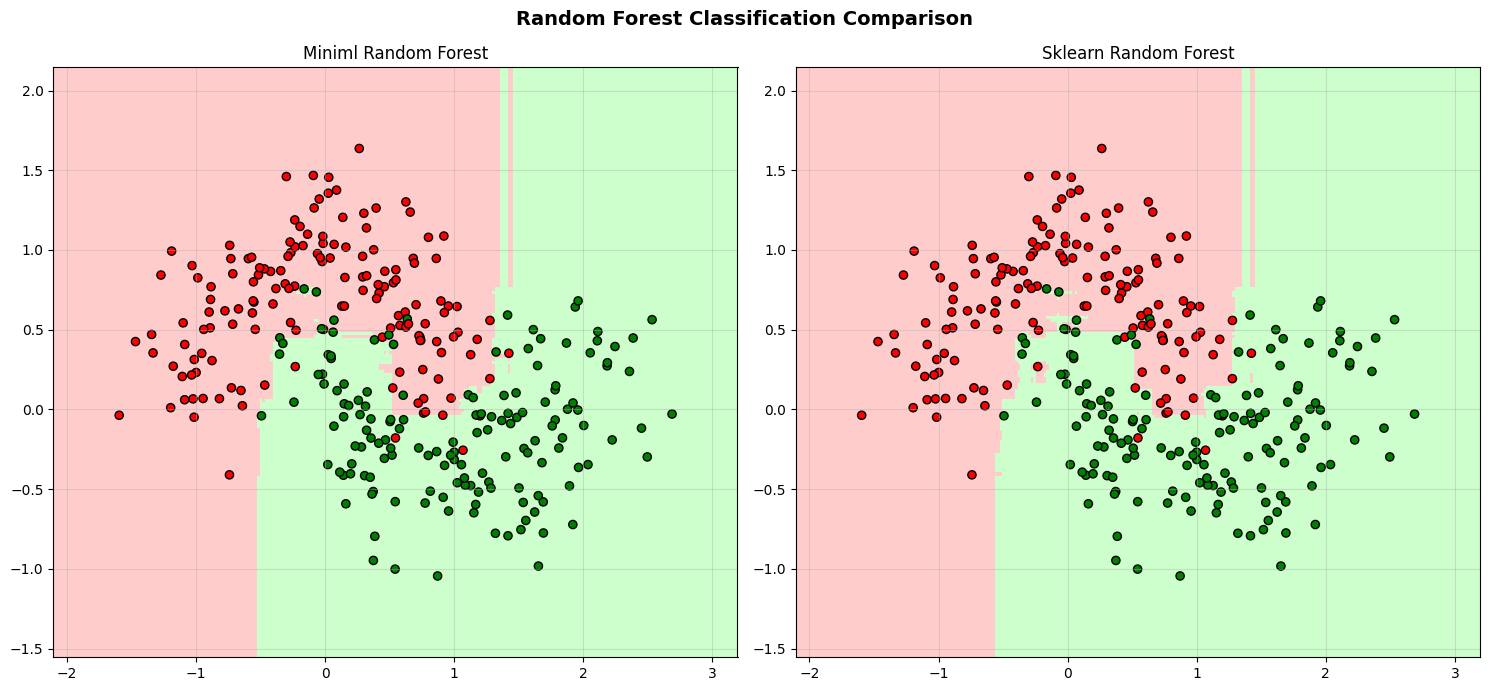

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier as SkRandomForestClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# DATASET
# ============================================================

X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

# ============================================================
# MODELS
# ============================================================

N_ESTIMATORS = 50
MAX_DEPTH = 8
MIN_SAMPLES_SPLIT = 2
MIN_SAMPLES_LEAF = 1
MAX_FEATURES = "sqrt"
CRITERION = "entropy"

custom_rf = RandomForestClassification(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    max_features=MAX_FEATURES,
    impurity_func=CRITERION,
    random_state=42
)

custom_rf.fit(X, y)


sk_rf = SkRandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    max_features=MAX_FEATURES,
    criterion=CRITERION,
    random_state=42
)

sk_rf.fit(X, y)

# ============================================================
# METRICS
# ============================================================

pred_custom = custom_rf.predict(X)
pred_sk = sk_rf.predict(X)

acc_custom = accuracy_score(y, pred_custom)
acc_sk = accuracy_score(y, pred_sk)

print("=" * 70)
print("RANDOM FOREST CLASSIFICATION")
print("=" * 70)
print(f"Accuracy (Miniml):  {acc_custom:.4f}")
print(f"Accuracy (Sklearn): {acc_sk:.4f}")
print(f"Prediction identity: {(pred_custom == pred_sk).mean()*100:.2f}%")
print("=" * 70)

# ============================================================
# DECISION BOUNDARY
# ============================================================

h = 0.02

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_custom = custom_rf.predict(grid).reshape(xx.shape)
Z_sk = sk_rf.predict(grid).reshape(xx.shape)

boundary_identity = (Z_custom == Z_sk).mean() * 100

print(f"Decision boundary identity: {boundary_identity:.2f}%")

# ============================================================
# VISUALIZATION
# ============================================================

cmap_light = ListedColormap(["#FFCCCC", "#CCFFCC"])
cmap_bold = ["red", "green"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].pcolormesh(
    xx,
    yy,
    Z_custom,
    cmap=cmap_light,
    shading="auto"
)

axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=[cmap_bold[i] for i in y],
    edgecolor="black",
    s=35
)

axes[0].set_title("Miniml Random Forest")
axes[0].grid(alpha=0.4)


axes[1].pcolormesh(
    xx,
    yy,
    Z_sk,
    cmap=cmap_light,
    shading="auto"
)

axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=[cmap_bold[i] for i in y],
    edgecolor="black",
    s=35
)

axes[1].set_title("Sklearn Random Forest")
axes[1].grid(alpha=0.4)

plt.suptitle(
    "Random Forest Classification Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()